# Time Series Decomposition: Pedestrian Injury Trends

**Goal:** Break down pedestrian injury counts into **trend**, **seasonality**, and **residual** components.

This shifts the analysis from *what conditions cause a single crash* to *how does injury risk evolve over time*.

---
### Why this matters for Vision Zero stakeholders
- **Trend** tells us: Is NYC getting safer or more dangerous overall?
- **Seasonality** tells us: Which months/days consistently spike every year?
- **Residual** tells us: Were there anomalous events (COVID lockdowns, policy changes) that disrupted normal patterns?

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully')

Libraries loaded successfully


## Step 1: Load and Prepare the Data

We need a **time-indexed** series of daily/monthly injury counts.
This is different from the EDA — instead of grouping by hour, we're building a continuous time series.

In [ ]:
df = pd.read_csv('/Users/Marcy_Student/Desktop/Capstone/Pedestrian-Injury-Risk-Predictor-Expanded/Data/cleaned_crash_data.csv')

# Ensure CRASH DATE is datetime
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'], errors='coerce')

print(f'Date range: {df["CRASH DATE"].min()} → {df["CRASH DATE"].max()}')
print(f'Total records: {len(df):,}')
print(f'Columns available: {list(df.columns[:10])}...')

Date range: 2022-01-02 00:00:00 → 2025-12-05 00:00:00
Total records: 340,858
Columns available: ['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE', 'LONGITUDE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME', 'OFF STREET NAME']...


In [8]:
# Build a monthly time series of total pedestrian injuries
monthly_injuries = (
    df.set_index('CRASH DATE')
      .resample('ME')['NUMBER OF PEDESTRIANS INJURED']   # 'ME' = Month End
      .sum()
      .rename('pedestrian_injuries')
)

# Drop any months with no data (incomplete boundary months)
monthly_injuries = monthly_injuries[monthly_injuries > 0]

print(f'Monthly series length: {len(monthly_injuries)} months')
print(monthly_injuries.head(10))

Monthly series length: 48 months
CRASH DATE
2022-01-31    617
2022-02-28    652
2022-03-31    725
2022-04-30    592
2022-05-31    572
2022-06-30    576
2022-07-31    641
2022-08-31    635
2022-09-30    678
2022-10-31    868
Freq: ME, Name: pedestrian_injuries, dtype: int64


## Step 2: Visualize the Raw Time Series

Before decomposing, always plot the raw signal. Look for:
- An overall upward/downward trend
- Repeating seasonal waves
- Any obvious anomalies (e.g., COVID 2020 drop)

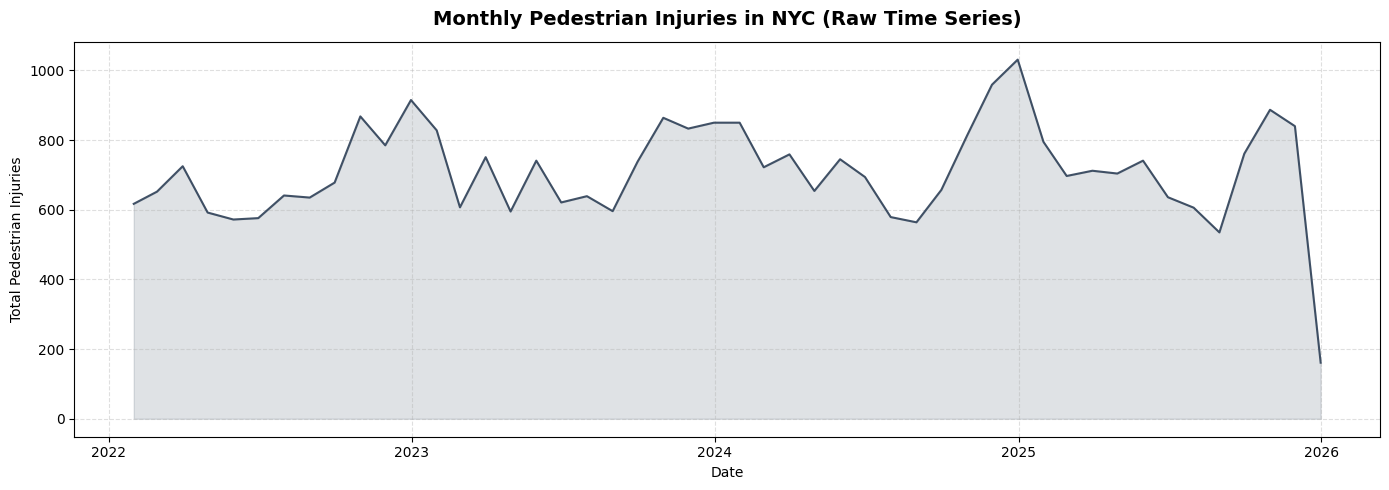


Descriptive stats:
count      48.0
mean      708.8
std       140.2
min       161.0
25%       620.0
50%       708.0
75%       799.5
max      1031.0
Name: pedestrian_injuries, dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_injuries.index, monthly_injuries.values, 
        color='#2E4057', linewidth=1.5, alpha=0.9)
ax.fill_between(monthly_injuries.index, monthly_injuries.values, 
                alpha=0.15, color='#2E4057')

ax.set_title('Monthly Pedestrian Injuries in NYC (Raw Time Series)', 
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Total Pedestrian Injuries')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'\nDescriptive stats:')
print(monthly_injuries.describe().round(1))

## Step 3: STL / Classical Decomposition

**Additive model** assumption: `Observed = Trend + Seasonality + Residual`

- **Additive** works well when the seasonal swings stay roughly the same size over time
- **Multiplicative** (`model='multiplicative'`) would be better if swings *grow* with the trend

We use `period=12` because there are 12 months in a year — one full seasonal cycle.

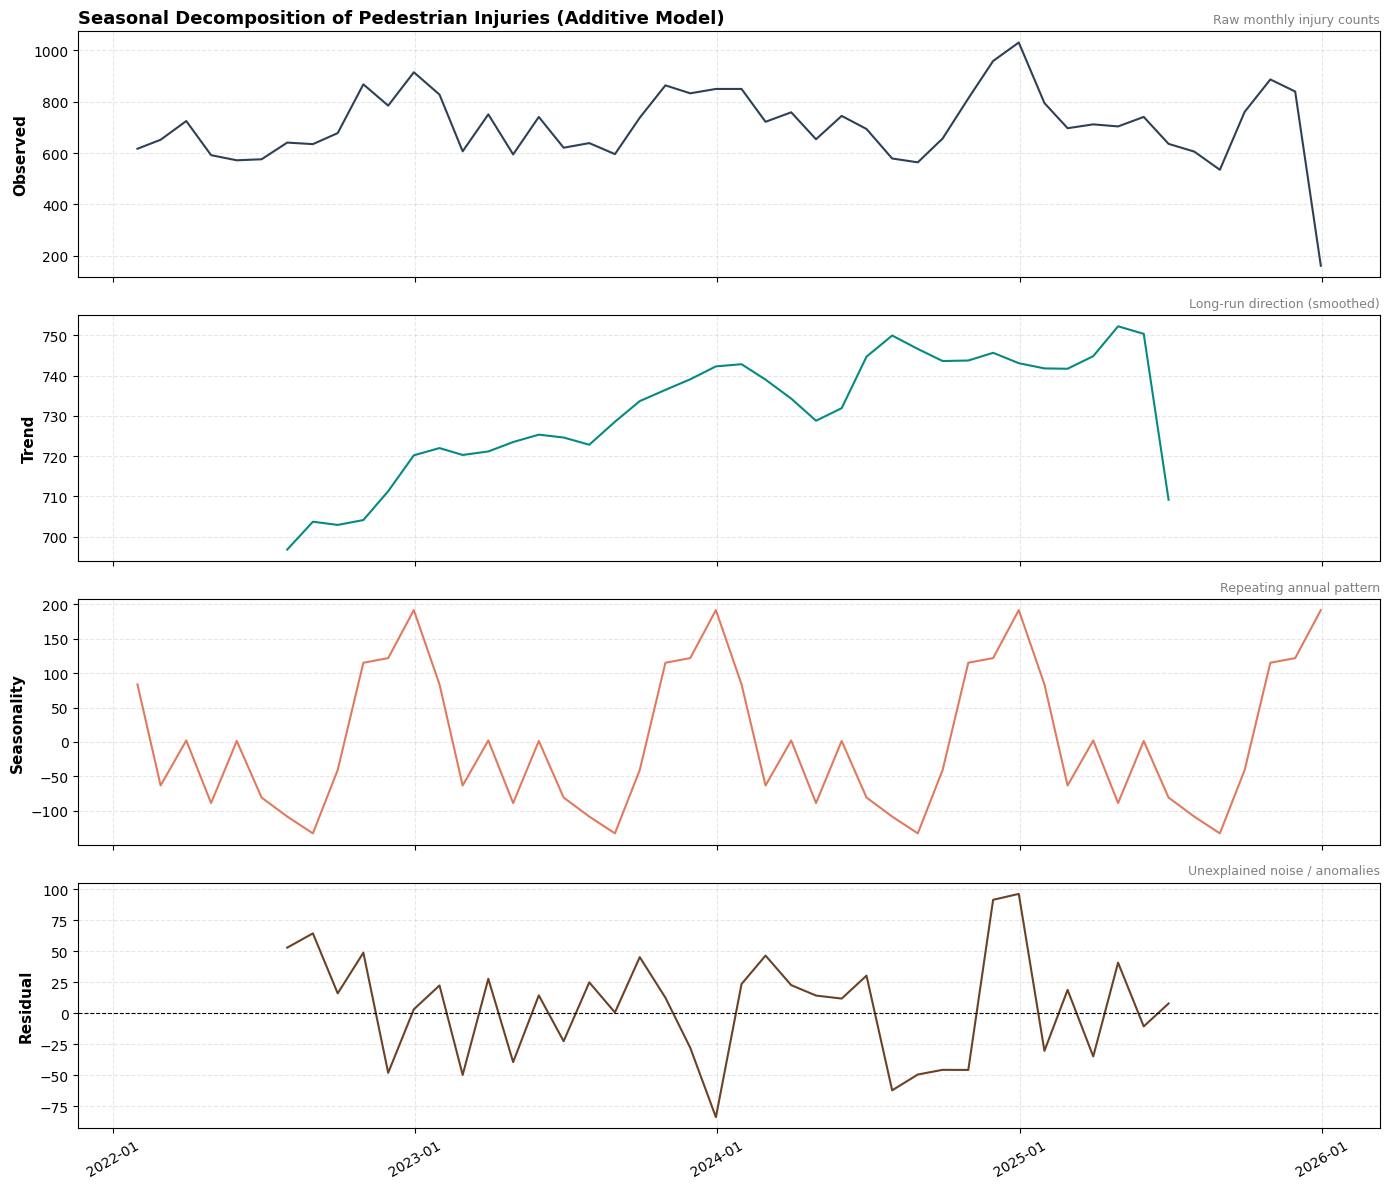

In [10]:
# Run decomposition (need at least 2 full seasonal cycles = 24 months)
decomposition = seasonal_decompose(
    monthly_injuries,
    model='additive',   # change to 'multiplicative' if seasonal amplitude grows with trend
    period=12           # 12-month annual cycle
)

# Plot all four components
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

components = [
    (monthly_injuries,          'Observed',   '#2E4057', 'Raw monthly injury counts'),
    (decomposition.trend,       'Trend',      '#048A81', 'Long-run direction (smoothed)'),
    (decomposition.seasonal,    'Seasonality','#E07A5F', 'Repeating annual pattern'),
    (decomposition.resid,       'Residual',   '#6B4226', 'Unexplained noise / anomalies'),
]

for ax, (data, label, color, subtitle) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=1.5)
    if label == 'Residual':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.set_title(subtitle, fontsize=9, color='gray', loc='right')
    ax.grid(True, linestyle='--', alpha=0.3)

axes[0].set_title('Seasonal Decomposition of Pedestrian Injuries (Additive Model)', 
                  fontsize=13, fontweight='bold', loc='left')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Step 4: Interpret Each Component

In [11]:
# --- Trend analysis ---
trend = decomposition.trend.dropna()

trend_start = trend.iloc[0]
trend_end   = trend.iloc[-1]
pct_change  = ((trend_end - trend_start) / trend_start) * 100

print('=== TREND COMPONENT ===')
print(f'  Trend at start : {trend_start:.0f} injuries/month')
print(f'  Trend at end   : {trend_end:.0f} injuries/month')
print(f'  Overall change : {pct_change:+.1f}%')
print(f'  Interpretation : NYC pedestrian injuries have {"decreased" if pct_change < 0 else "increased"} '
      f'by {abs(pct_change):.1f}% over the observed period.')

print()

=== TREND COMPONENT ===
  Trend at start : 697 injuries/month
  Trend at end   : 709 injuries/month
  Overall change : +1.8%
  Interpretation : NYC pedestrian injuries have increased by 1.8% over the observed period.



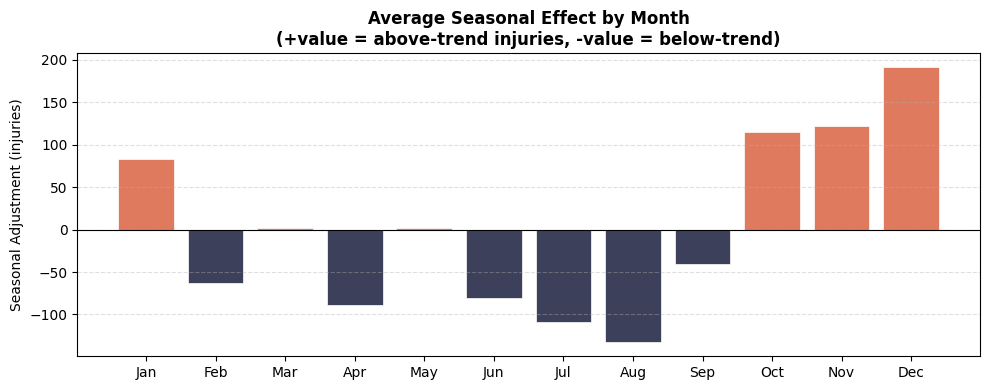


=== SEASONAL COMPONENT ===
  Peak months (highest above-trend risk):
    Dec: +192 injuries above trend
    Nov: +122 injuries above trend
    Oct: +115 injuries above trend
  Safest months (lowest seasonal risk):
    Aug: -133 injuries below trend
    Jul: -109 injuries below trend
    Apr: -89 injuries below trend


In [12]:
# --- Seasonality analysis ---
seasonal = decomposition.seasonal

# Average seasonal effect by month number
seasonal_by_month = seasonal.groupby(seasonal.index.month).mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
seasonal_by_month.index = month_names

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#E07A5F' if v > 0 else '#3D405B' for v in seasonal_by_month.values]
ax.bar(seasonal_by_month.index, seasonal_by_month.values, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Seasonal Effect by Month\n(+value = above-trend injuries, -value = below-trend)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Seasonal Adjustment (injuries)')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('\n=== SEASONAL COMPONENT ===')
print('  Peak months (highest above-trend risk):')
top3 = seasonal_by_month.nlargest(3)
for m, v in top3.items():
    print(f'    {m}: +{v:.0f} injuries above trend')
print('  Safest months (lowest seasonal risk):')
bot3 = seasonal_by_month.nsmallest(3)
for m, v in bot3.items():
    print(f'    {m}: {v:.0f} injuries below trend')

In [13]:
# --- Residual analysis: flag anomalous months ---
resid = decomposition.resid.dropna()

resid_std  = resid.std()
resid_mean = resid.mean()

# Flag months more than 2 standard deviations from mean
anomalies = resid[abs(resid - resid_mean) > 2 * resid_std]

print('=== RESIDUAL COMPONENT ===')
print(f'  Residual std dev: {resid_std:.0f} injuries')
print(f'  Anomalous months (>2σ from expected):')
if len(anomalies) > 0:
    for date, val in anomalies.sort_values().items():
        direction = 'SPIKE' if val > 0 else 'DROP'
        print(f'    {date.strftime("%Y-%m")} → {direction} of {val:+.0f} injuries')
else:
    print('    None detected at 2σ threshold')

print('\n  Interpretation: Large negative residuals likely indicate external events')
print('  (e.g., COVID lockdowns in 2020) that reduced traffic unexpectedly.')

=== RESIDUAL COMPONENT ===
  Residual std dev: 43 injuries
  Anomalous months (>2σ from expected):
    2023-12 → DROP of -84 injuries
    2024-11 → SPIKE of +91 injuries
    2024-12 → SPIKE of +96 injuries

  Interpretation: Large negative residuals likely indicate external events
  (e.g., COVID lockdowns in 2020) that reduced traffic unexpectedly.


## Step 5: Borough-Level Decomposition

Does each borough follow the same seasonal pattern, or do some diverge?
This can reveal whether safety interventions in a specific borough disrupted normal patterns.

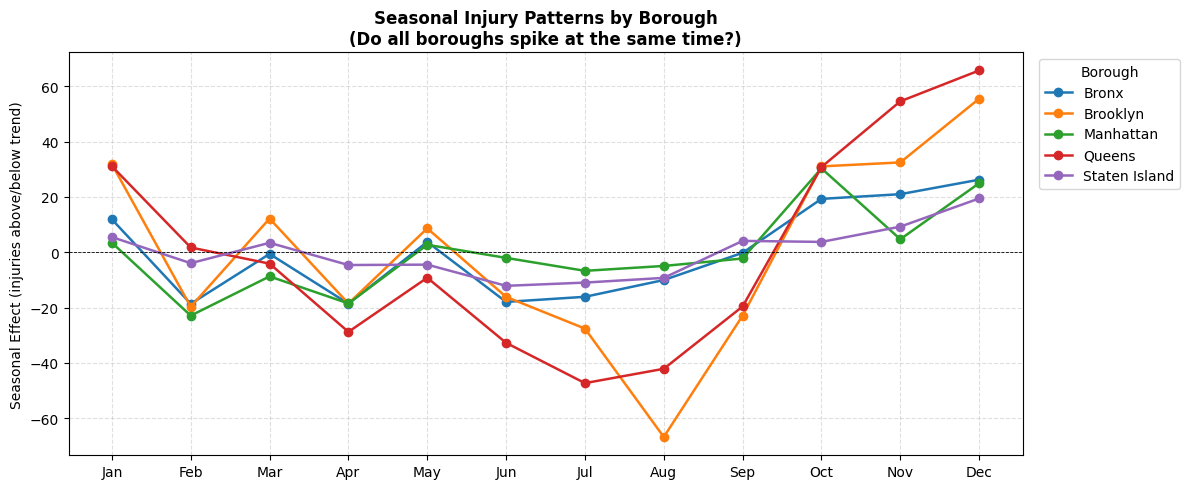

In [14]:
boroughs = df['BoroName'].dropna().unique()
borough_seasonal = {}

for boro in sorted(boroughs):
    boro_series = (
        df[df['BoroName'] == boro]
          .set_index('CRASH DATE')
          .resample('ME')['NUMBER OF PEDESTRIANS INJURED']
          .sum()
    )
    boro_series = boro_series[boro_series > 0]
    
    if len(boro_series) >= 24:  # need at least 2 years for decomposition
        try:
            dec = seasonal_decompose(boro_series, model='additive', period=12)
            seasonal_avg = dec.seasonal.groupby(dec.seasonal.index.month).mean()
            borough_seasonal[boro] = seasonal_avg
        except Exception as e:
            print(f'  Skipping {boro}: {e}')

# Plot borough seasonality comparison
seasonal_df = pd.DataFrame(borough_seasonal)
seasonal_df.index = month_names

fig, ax = plt.subplots(figsize=(12, 5))
for col in seasonal_df.columns:
    ax.plot(seasonal_df.index, seasonal_df[col], marker='o', linewidth=1.8, label=col)

ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.set_title('Seasonal Injury Patterns by Borough\n(Do all boroughs spike at the same time?)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Seasonal Effect (injuries above/below trend)')
ax.legend(title='Borough', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Step 6: Export Decomposed Components

Save trend + seasonality + residual as a CSV so it can be used by the forecasting notebook.

In [15]:
decomp_df = pd.DataFrame({
    'observed':   decomposition.observed,
    'trend':      decomposition.trend,
    'seasonal':   decomposition.seasonal,
    'residual':   decomposition.resid,
})

decomp_df.index.name = 'date'
decomp_df.to_csv('../Data/decomposed_injuries.csv')

print('Exported decomposed_injuries.csv')
print(decomp_df.tail())

Exported decomposed_injuries.csv
            observed  trend    seasonal  residual
date                                             
2025-08-31     535.0    NaN -133.063657       NaN
2025-09-30     761.0    NaN  -40.841435       NaN
2025-10-31     887.0    NaN  115.116898       NaN
2025-11-30     840.0    NaN  121.880787       NaN
2025-12-31     161.0    NaN  191.700231       NaN


---
## Summary

| Component | What it tells us | Stakeholder use |
|-----------|------------------|-----------------|
| **Trend** | Is NYC getting safer over time? | Track long-term Vision Zero progress |
| **Seasonality** | Which months are structurally riskier? | Pre-deploy safety resources before peak months |
| **Residual** | What was unexpected? | Evaluate whether specific interventions worked |

**Next step:** Use this decomposed series as input for the forecasting model (`02_forecasting_model.ipynb`).